
## NIO and cost






## Inputs



(2, 'i_h2i_rate')

(3, 'i_pci_rate')

(5, 'i_ngi_rate')

(6, 'i_o2_volfract')

(8, 'i_h2_temp')

(9, 'i_hbtemp')

(10, 'i_wind_rt')


## Outputs


* desired output requirements 


(27, 'o_tgt')

(29, 'o_hmt')

(39, 'o_prod_rt')

(40, 'o_fta')

(28, 'o_coke_rt')



In [1]:

## !pip install xgboost
## !pip install onnxmltools
## !pip install onnxruntime
## !pip install pandas
## !pip install scikit-learn
## !pip install matplotlib
## !pip install seaborn
## !pip install mlxtend
## ! pip install skl2onnx



In [2]:


import torch
import numpy as np
import pandas as pd
import sklearn
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import math
import seaborn as sns
import random
import functorch


import torch.optim as optim


from numpy.random import normal
from scipy.stats import norm
import scipy.stats as stats
from numpy import hstack
from numpy import vstack
from numpy import exp
from sklearn.neighbors import KernelDensity

##from typing import Optional

from torch import Tensor


from torch.utils.data import TensorDataset, DataLoader

from mlxtend.plotting import heatmap

## coefficient of determination (R**2)
from sklearn.metrics import r2_score

np.set_printoptions(suppress=True)
torch.set_printoptions(sci_mode=False)

import os, json, time, uuid


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score





In [3]:


import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor, DMatrix, train as train_xgb
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import onnxmltools
from onnxmltools.convert.xgboost.operator_converters.XGBoost import (
    convert_xgboost)
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster


from zipfile import ZipFile
from skl2onnx.common.data_types import FloatTensorType
from skl2onnx import convert_sklearn, to_onnx, update_registered_converter
from skl2onnx.common.shape_calculator import (
    calculate_linear_classifier_output_shapes,
    calculate_linear_regressor_output_shapes)


# Import the ONNX runtime environment
import onnxruntime as rt




/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/onnx_ops.py:159: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  tys = obj.typeStr or ''
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/automation.py:154: UserWarning: OpSchema.FormalParameter.isHomogeneous is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.is_homogeneous instead.
  if getattr(obj, 'isHomogeneous', False):
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/jinja2/environment.py:485: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  return getattr(obj, attribute)


In [4]:

import PDFshapingUtils as PDF_tk


In [5]:

PDFshapingOBJ = PDF_tk.PDFshapingUtils()


In [6]:

PDFshapingOBJ.read_csv_file_with_pandas('CFD.16.2025.csv')


In [7]:

## Ty suggested fix where 0 needs to be 300

PDFshapingOBJ.CFD_raw_data["i_h2_temp"] = PDFshapingOBJ.CFD_raw_data["i_h2_temp"].replace(0, 300)


In [8]:

PDFshapingOBJ.CFD_raw_data


,index,case name,i_h2i_rate,i_pci_rate,i_wpi_rate,i_ngi_rate,i_o2_volfract,i_ng_temp,i_h2_temp,i_hbtemp,...,o_h2o_sollos,o_feo_sollos,o_hm_rt,o_mw_rt,o_wf_rt,o_hm_h2share,o_mw_h2share,o_wf_h2share,o_prod_rt,o_fta
0,1,H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HB...,0,0,0,120,21,300,300,1200,...,20.0,44.9,122.0,264.0,687.0,31.6,26.7,63.5,4050.0,1800.0
1,2,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,18.5,52.6,122.0,265.0,684.0,27.9,23.4,60.6,4060.0,1850.0
2,3,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.6,50.9,123.0,266.0,690.0,27.7,23.5,60.8,4080.0,1850.0
3,4,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.2,124.0,268.0,690.0,27.7,23.2,60.6,4090.0,1850.0
4,5,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.4,124.0,268.0,695.0,27.7,23.2,60.7,4110.0,1850.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,4995,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,18.7,40.3,353.0,763.0,2190.0,34.0,20.5,56.7,11700.0,2380.0
4995,4996,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,18.7,40.7,353.0,763.0,2190.0,33.8,20.4,56.8,11700.0,2310.0
4996,4997,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,19.2,37.5,353.0,763.0,2230.0,33.6,20.4,57.1,11700.0,2380.0
4997,4998,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,17.6,39.8,355.0,768.0,2220.0,34.0,20.0,55.7,11800.0,2310.0


In [9]:

PDFshapingOBJ.print_headers_list()


['index', 'case name', 'i_h2i_rate', 'i_pci_rate', 'i_wpi_rate', 'i_ngi_rate', 'i_o2_volfract', 'i_ng_temp', 'i_h2_temp', 'i_hbtemp', 'i_wind_rt', 'i_blastH2O', 'i_BdnH2O', 'i_sgi_rate', 'i_sgtemp', 'i_sgi_H2COratio', 'i_sgi_ReProRatio', 'o_tuy_velo', 'o_tuy_temp', 'o_burn', 'o_delp', 'o_co_vf', 'o_co2_vf', 'o_h2_vf', 'o_n2_vf', 'o_co_util', 'o_h2_util', 'o_tgt', 'o_coke_rt', 'o_hmt', 'o_co2_sollos', 'o_h2o_sollos', 'o_feo_sollos', 'o_hm_rt', 'o_mw_rt', 'o_wf_rt', 'o_hm_h2share', 'o_mw_h2share', 'o_wf_h2share', 'o_prod_rt', 'o_fta']
41
(0, 'index')
(1, 'case name')
(2, 'i_h2i_rate')
(3, 'i_pci_rate')
(4, 'i_wpi_rate')
(5, 'i_ngi_rate')
(6, 'i_o2_volfract')
(7, 'i_ng_temp')
(8, 'i_h2_temp')
(9, 'i_hbtemp')
(10, 'i_wind_rt')
(11, 'i_blastH2O')
(12, 'i_BdnH2O')
(13, 'i_sgi_rate')
(14, 'i_sgtemp')
(15, 'i_sgi_H2COratio')
(16, 'i_sgi_ReProRatio')
(17, 'o_tuy_velo')
(18, 'o_tuy_temp')
(19, 'o_burn')
(20, 'o_delp')
(21, 'o_co_vf')
(22, 'o_co2_vf')
(23, 'o_h2_vf')
(24, 'o_n2_vf')
(25, 'o_co_ut

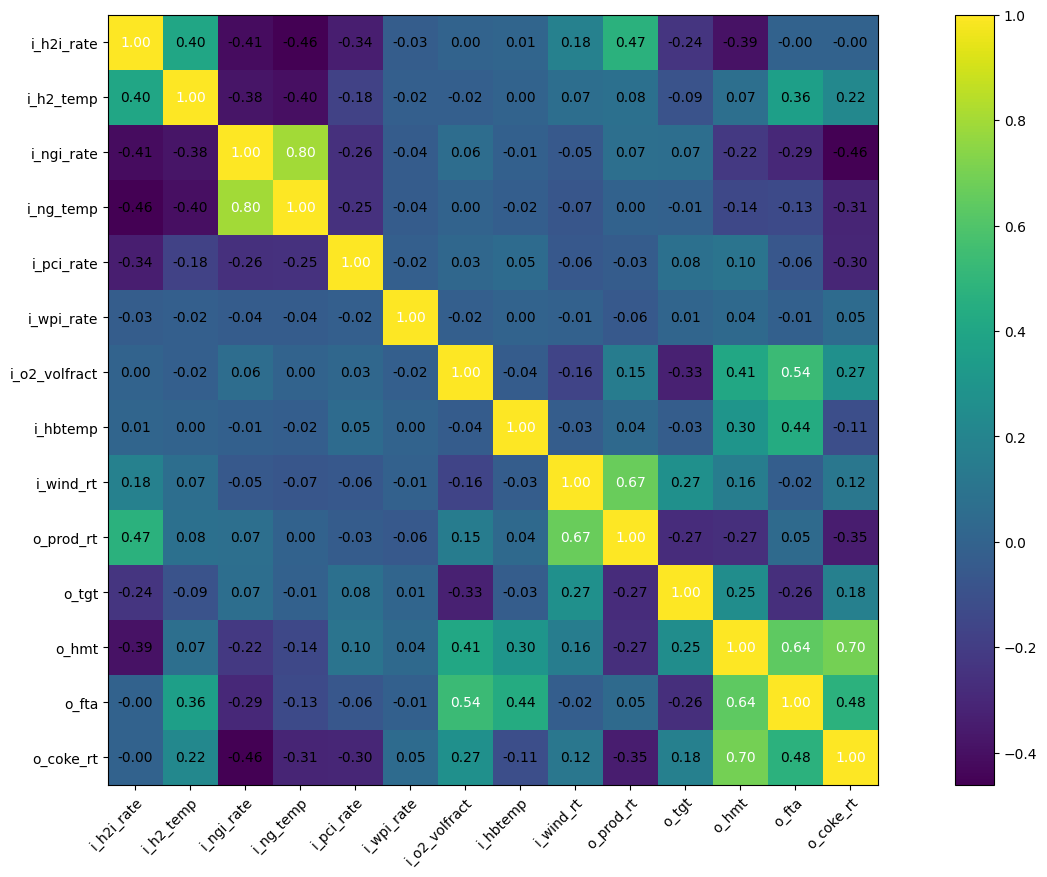

In [10]:


PDFshapingOBJ.list_of_selected_column_names = ['i_h2i_rate','i_h2_temp','i_ngi_rate','i_ng_temp','i_pci_rate',
                    'i_wpi_rate','i_o2_volfract',
                    'i_hbtemp','i_wind_rt','o_prod_rt', 'o_tgt', 'o_hmt','o_fta', 'o_coke_rt']



PDFshapingOBJ.print_correlation_coefficients()


In [11]:

PDFshapingOBJ.convert_pd_data_to_numpy()


[[1
  'H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-7_SGI-0_SGT-0_SGC_0 '
  0 ... 63.5 4050.0 1800.0]
 [2
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-1_SGI-0_SGT-0_SGC_0 '
  0 ... 60.6 4060.0 1850.0]
 [3
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  0 ... 60.8 4080.0 1850.0]
 ...
 [4997
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1600_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 57.1 11700.0 2380.0]
 [4998
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-3_SGI-0_SGT-0_SGC_0 '
  30 ... 55.7 11800.0 2310.0]
 [4999
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 56.2 11800.0 2310.0]]
(4999, 41)


In [12]:

PDFshapingOBJ.gen_X_y_for_selected_indeces(  
                   inputs = [  2, 3, 5, 6, 8, 9, 10   ] , 
                   outputs= [ 27, 29, 39, 40, 28 ]   
)


## inputs = [ 2, 3, 5, 6, 8, 9, 10  ]          ## the full 7



7
5


In [13]:

print(PDFshapingOBJ.X.shape)
print(PDFshapingOBJ.y.shape)


(4999, 7)
(4999, 5)


In [14]:

PDFshapingOBJ.random_seed = int( random.random() * 100  )         ## defautl is 42


In [15]:

PDFshapingOBJ.split_np_data_train_test(selected_test_size=0.2)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [16]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [17]:

'''


from sklearn.decomposition import PCA

# Instantiate PCA to reduce to 4 components
pca = PCA(n_components=4)

# Fit on training data and transform both train and test
X_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)
X_test_pca  = pca.transform(PDFshapingOBJ.X_test)

# Replace the original inputs with PCA-reduced versions
PDFshapingOBJ.X_train = X_train_pca
PDFshapingOBJ.X_test  = X_test_pca


'''


'\n\n\nfrom sklearn.decomposition import PCA\n\n# Instantiate PCA to reduce to 4 components\npca = PCA(n_components=4)\n\n# Fit on training data and transform both train and test\nX_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)\nX_test_pca  = pca.transform(PDFshapingOBJ.X_test)\n\n# Replace the original inputs with PCA-reduced versions\nPDFshapingOBJ.X_train = X_train_pca\nPDFshapingOBJ.X_test  = X_test_pca\n\n\n'

In [18]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [19]:

PDFshapingOBJ.convert_dataset_from_np_to_torch()


In [20]:

PDFshapingOBJ.standardize_X_scales()
PDFshapingOBJ.standardize_y_scales()


In [21]:


PDFshapingOBJ.gen_Dataloader_train()

PDFshapingOBJ.train_dl



## Model Forward ( 7x4 )


In [22]:

n_inputs  = 7     ## 7
n_outputs = 5




#############################################################
##   F1      plus       F2
## Linear     +      Nonlinear

class F1plusF2_SIO_Forward(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations,  device='cuda'):
        super().__init__()
        self.device = device
        
        ## self.x_means      = x_means
        ## self.x_deviations = x_deviations
        ## self.y_means      = y_means
        ## self.y_deviations = y_deviations
        
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)
        
        
        
        ## F1
        self.f1_linear1 = nn.Linear(n_inputs, n_outputs)       
        
        ## F2
        self.f2_linear1 = nn.Linear(n_inputs, 10)
        self.f2_act1    = nn.Tanh()   ## nn.Sigmoid()    ## Tanh()    nn.ReLU()                 
        self.f2_linear2 = nn.Linear(10, n_outputs)       
        self.f2_dropout = nn.Dropout(0.25)
        
        # Move model to device
        self.to(self.device)
        
        
    ## perform inference
    def forward(self, x):
        x = x.to(self.device)
        x = (x - self.x_means) / self.x_deviations
        
        ## F1
        f1 = self.f1_linear1(x)
        
        ## F2
        f2 = self.f2_linear1(x)
        f2 = self.f2_act1(f2)
        f2 = self.f2_dropout(f2)
        f2 = self.f2_linear2(f2)
        
        
        y_scaled   = f1 + f2
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        ##   y_descaled = torch.clamp(  y_descaled, min=0.0  )
        
        return y_descaled, y_scaled
    




In [23]:

n_inputs  = 7    ## 7
n_outputs = 5





    
class ResidualNet_Forward(nn.Module):
    def __init__(self, x_means, x_deviations, y_means, y_deviations, dropout_rate=0.1, device='cuda'):
        
        super().__init__()
        self.device = device
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)

     
        self.fc1  = nn.Linear(n_inputs, 64)
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(64, 64)
        self.act2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(64, n_outputs)

        # If input_dim ≠ 64, project for residual addition
        self.input_proj = nn.Linear(n_inputs, 64) if n_inputs != 64 else nn.Identity()
        
        # Move model to device
        self.to(self.device)
        

    def forward(self, x):
        x  = x.to(self.device)
        x  = (x - self.x_means) / self.x_deviations
        x0 = self.input_proj(x)
        x1 = self.dropout1(self.act1(self.fc1(x)))
        x2 = self.dropout2(self.act2(self.fc2(x1)))
        x_res = x2 + x0
        y_scaled = self.fc3(x_res)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    

    


In [24]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## model_Forward     = F1plusF2_SIO_Forward(

model_Forward     =     F1plusF2_SIO_Forward(
                         PDFshapingOBJ.x_means, 
                         PDFshapingOBJ.x_deviations, 
                         PDFshapingOBJ.y_means, 
                         PDFshapingOBJ.y_deviations,
                         device=device  # pass device into the model
    
)

optimizer = optim.Adam(model_Forward.parameters(), lr=0.001)
loss_fn   = nn.MSELoss()



In [25]:

model_Forward.train()

for epoch in range(1000):
    for xb, yb in PDFshapingOBJ.train_dl:
        
        xb = xb.to(model_Forward.device)
        yb = yb.to(model_Forward.device)
        
        optimizer.zero_grad()
        pred_descaled, pred_scaled = model_Forward(xb)
        
        loss = loss_fn(pred_scaled, yb)
        loss.backward()
        optimizer.step()
    if epoch % 100 == 0:
        print(epoch, ".....", loss.item() ) 
    



0 ..... 0.5391898155212402
100 ..... 0.19678978621959686
200 ..... 0.34505507349967957
300 ..... 0.397845596075058
400 ..... 0.20111335813999176
500 ..... 0.26860761642456055
600 ..... 0.23343877494335175
700 ..... 0.3628922700881958
800 ..... 0.19162951409816742
900 ..... 0.10345164686441422


In [26]:

print("=== SANITY CHECK: SCALING ===")
print("y_means:", PDFshapingOBJ.y_means)
print("y_deviations:", PDFshapingOBJ.y_deviations)

print("===============================================")

print("x_means:", PDFshapingOBJ.x_means)
print("x_deviations:", PDFshapingOBJ.x_deviations)


=== SANITY CHECK: SCALING ===
y_means: tensor([[  97.8454, 1294.5311, 8424.4287, 2303.8853,  417.1996]])
y_deviations: tensor([[  51.0207,  524.1351, 1509.7509,  210.1413,   50.0837]])
x_means: tensor([[  12.3281,   18.3018,   41.8247,   25.5756,  412.0030, 1437.9855,
          198.3521]])
x_deviations: tensor([[ 15.0938,  44.8833,  46.7100,   3.3098, 266.9488, 157.5394,  26.4330]])


In [27]:

print(PDFshapingOBJ.y_means -  PDFshapingOBJ.y_deviations)
print(PDFshapingOBJ.y_means +  PDFshapingOBJ.y_deviations)


tensor([[  46.8246,  770.3960, 6914.6777, 2093.7439,  367.1158]])
tensor([[ 148.8661, 1818.6663, 9934.1797, 2514.0266,  467.2833]])


In [28]:

print(PDFshapingOBJ.x_means -  PDFshapingOBJ.x_deviations)
print(PDFshapingOBJ.x_means +  PDFshapingOBJ.x_deviations)


tensor([[  -2.7657,  -26.5815,   -4.8853,   22.2658,  145.0542, 1280.4460,
          171.9191]])
tensor([[  27.4219,   63.1852,   88.5348,   28.8855,  678.9518, 1595.5249,
          224.7850]])


In [29]:

import numpy as np
from numpy.linalg import norm

# --- distance function ---
def euclid(a, b):
    return norm(a - b)



## Now add Costs


In [30]:

def regularize_z(z, strength=1e-3):
    
    return strength * torch.sum(z**2)


In [31]:

def soft_box_penalty(x, lower, upper, strength=1.0):     ## strength=10.0
    
    return strength * ((torch.relu(lower - x) ** 2).sum() + (torch.relu(x - upper) ** 2).sum())


In [32]:

def soft_box_penalty2(x, lower, upper, beta=0.01):
    
    # original constraint penalty
    violation = (torch.relu(lower - x)**2 + torch.relu(x - upper)**2).sum()
    
    # NEW: center stabilizer
    center      = (lower + upper) / 2
    center_pull = ((x - center)**2).mean()
    
    return violation + beta * center_pull


In [33]:

clamp_min = torch.tensor([[   0,   0,   0,    21,   300,   1200, 150 ]])     ## from Ty
clamp_max = torch.tensor([[ 300, 300, 300,    90,  3000,   1500, 220 ]])


get_x_from_z = lambda z: clamp_min + (clamp_max - clamp_min) * torch.sigmoid(z)


In [34]:


y_clamp_min = torch.tensor([[  100,  1710,   6400,    2000,   200 ]])     ## from Ty
y_clamp_max = torch.tensor([[  150,  1800,   6600,    2600,   500 ]])


y_clamp_min =  (y_clamp_min  - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations
y_clamp_max =  (y_clamp_max  - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations


In [35]:

def wrapped_model(x):
    y_descaled, _ = model_Forward(x)
    return y_descaled  



In [36]:

price_real = np.array([4.0, 1.0, 0.5, 0.0, 0.0, 0.0, 0.0])

price_real = torch.tensor(price_real, dtype=torch.float32)


model_Forward.eval()


for p in model_Forward.parameters():
    p.requires_grad = False



In [37]:


## lambda_cost = 0.0

dist_method_A = []
dist_method_B = []
cost_diffs    = [] 
cost_diff     = 0

actual_pred_cost = []
actual_real_cost = []

percent_diffs = []
percent_diff  = 0 

learning_rate = 0.01        ## 0.001      ## 1e-5


In [72]:



for i in range(  1, PDFshapingOBJ.X_test.shape[0]  ):
    
    target_y  = torch.tensor( PDFshapingOBJ.y_test[i]   )    ## what you want y ?
    x_real    = torch.tensor( PDFshapingOBJ.X_test[i]   )    ## real x
    
    target_y  = (target_y  - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations
    
    ## x_starting_point = torch.tensor(   PDFshapingOBJ.X_test[0]   )    ## starting point
    ## x_temp = x_starting_point.clone().detach().requires_grad_(True)
    ## z_init = torch.rand((1,7))*0.4 + 0.3
    
    z_init = torch.rand((1,7))*0.2 + 0.3
    z = torch.nn.Parameter(torch.logit(z_init))    ## this requires grad 
          

    ## x_temp = torch.randn_like(x_starting_point).requires_grad_(True)

    optimizer = torch.optim.Adam([z], lr=learning_rate)
    
   
    
    for j in range(2000):             ## 1000
        
        optimizer.zero_grad()
        
        x_temp = get_x_from_z(  z  )
        
        _, current_y = model_Forward(x_temp)
        
   
        
        ## current_y = y_clamp_min + (y_clamp_max - y_clamp_min) * torch.sigmoid(current_y)
        
        
        loss_z_reg = regularize_z(z, strength=1e-3)
        
        loss_main    = torch.mean((current_y - target_y)**2)
        loss_ranges  = soft_box_penalty(current_y, y_clamp_min, y_clamp_max)
        loss_cost    = x_temp @ price_real
        
        lambda_cost   =   0.01        ## 0.1    
        alpha         =   0.7
        
        
        ##  loss     =   0.4 * loss_cost + 0.3 * loss_ranges + 0.3 * loss_main
        
        loss_coke    = current_y[:, 4].mean()
        
        loss         = loss_main + 0.01 * loss_cost + 10 * loss_ranges + 10*loss_coke 
  
   
        loss.backward()
        optimizer.step()
        
        
    
        #######################
        
     
        x_temp_pred_np   = x_temp.detach().numpy()
        ## cost_pred        = np.dot(   price_real, x_temp_pred_np)
        cost_pred        = torch.dot(price_real, x_temp.squeeze()).item()
        
        x_real_np        = x_real.detach().numpy() 
        cost_real        = np.dot(price_real, x_real_np)
       
        if j % 400 == 0:           ## 20
            print(f"iteration {j} cost: {cost_pred}......H2, PCI, NGI:", x_temp_pred_np[:,:3] )
            print("real cost       :", cost_real)
            print( "                       total loss",     loss.item()      )
            print( "                  loss_main (MSE)",      loss_main        )
            print( "                       loss_cost",      loss_cost.item() )
            print( "                       loss_ranges",  loss_ranges.item() )
        
   
        cost_diff = cost_pred - cost_real
        if cost_real > 0:                         ## handle nans
            percent_diff = cost_diff / cost_real
            percent_diffs.append(percent_diff)
        
          
    cost_diffs.append(    cost_diff  )
    
    actual_pred_cost.append(  cost_pred  )
    actual_real_cost.append(  cost_real  )
      

    the_cols = "    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt"
    
    
    print("...")
    print("...")
    print("...")
    print( the_cols )
    print( "pred" )
    print( x_temp_pred_np )
    print( "real" )
    print( x_real_np )
    print("...")
    
    
    print( "o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt" )
    print( "y pred" )
    print( wrapped_model(torch.from_numpy(x_temp_pred_np))   )
    print( "y real" )
    print( wrapped_model(torch.from_numpy(x_real_np))   )
    
    dist_method_A.append( euclid(x_temp_pred_np, x_real_np) )
    dist_method_B.append( euclid(
                    wrapped_model(torch.from_numpy(x_temp_pred_np)).detach().numpy() , 
                    wrapped_model(torch.from_numpy(x_real_np)).detach().numpy()
    ))
    
    print(i)
    print('*******************************************************')
    
    ##########################################
    
    if i == 1:
        percent_errors = [[] for _ in range(5)]  # one list per output

    y_pred_np = wrapped_model(torch.from_numpy(x_temp_pred_np)).detach().numpy().flatten()
    y_real_np = wrapped_model(torch.from_numpy(x_real_np)).detach().numpy().flatten()

    # % error per variable
    pct = (y_pred_np - y_real_np) / (y_real_np + 1e-8) * 100

    for k in range(5):
         percent_errors[k].append(pct[k])




iteration 0 cost: 684.1451416015625......H2, PCI, NGI: [[133.85448  91.41571 114.62304]]
real cost       : 90.0
                       total loss 700.5653076171875
                  loss_main (MSE) tensor(11.7403, grad_fn=<MeanBackward0>)
                       loss_cost 684.1451416015625
                       loss_ranges 72.53934478759766
iteration 400 cost: 163.39971923828125......H2, PCI, NGI: [[30.499886 27.074966 28.650429]]
real cost       : 90.0
                       total loss 29.607315063476562
                  loss_main (MSE) tensor(1.9923, grad_fn=<MeanBackward0>)
                       loss_cost 163.39971923828125
                       loss_ranges 3.202568292617798
iteration 800 cost: 131.30567932128906......H2, PCI, NGI: [[18.269928 47.838066 20.775816]]
real cost       : 90.0
                       total loss 10.652032852172852
                  loss_main (MSE) tensor(2.2098, grad_fn=<MeanBackward0>)
                       loss_cost 131.30567932128906
                

...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   6.262112   98.98631    29.151293   22.830498 2864.268    1495.4923
   157.20503 ]]
real
[   0.    0.  100.   24.  300. 1200.  160.]
...
o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt
y pred
tensor([[  89.4732, 1238.6456, 7116.6816, 2652.4629,  331.9640]])
y real
tensor([[ 115.8881,  786.2925, 6148.4175, 2001.4814,  391.3727]])
4
*******************************************************
iteration 0 cost: 585.4203491210938......H2, PCI, NGI: [[ 91.037704 148.67943  145.18013 ]]
real cost       : 50.0
                       total loss 516.4097290039062
                  loss_main (MSE) tensor(16.1601, grad_fn=<MeanBackward0>)
                       loss_cost 585.4203491210938
                       loss_ranges 54.80596160888672
iteration 400 cost: 180.4400177001953......H2, PCI, NGI: [[21.78734 71.97665 42.62802]]
real cost       : 50.0
                       total loss 18.733226776

iteration 1200 cost: 152.5095977783203......H2, PCI, NGI: [[12.012335 93.32053  22.279453]]
real cost       : 200.0
                       total loss 0.37267017364501953
                  loss_main (MSE) tensor(1.2711, grad_fn=<MeanBackward0>)
                       loss_cost 152.5095977783203
                       loss_ranges 1.2009098529815674
iteration 1600 cost: 146.20306396484375......H2, PCI, NGI: [[ 9.414614 96.812996 23.463211]]
real cost       : 200.0
                       total loss -1.8274507522583008
                  loss_main (MSE) tensor(1.4035, grad_fn=<MeanBackward0>)
                       loss_cost 146.20306396484375
                       loss_ranges 1.0792262554168701
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   7.524059   99.39552    27.042515   23.365856 2852.6316   1495.3987
   156.61751 ]]
real
[  50.    0.    0.   30. 1200. 1600.  195.]
...
o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt
y pred


iteration 400 cost: 160.06300354003906......H2, PCI, NGI: [[21.13153  63.272465 24.528837]]
real cost       : 20.5
                       total loss 17.52036476135254
                  loss_main (MSE) tensor(1.7959, grad_fn=<MeanBackward0>)
                       loss_cost 160.06300354003906
                       loss_ranges 2.0372323989868164
iteration 800 cost: 148.08743286132812......H2, PCI, NGI: [[13.237362 83.33082  23.61431 ]]
real cost       : 20.5
                       total loss 3.834113121032715
                  loss_main (MSE) tensor(1.9454, grad_fn=<MeanBackward0>)
                       loss_cost 148.08743286132812
                       loss_ranges 1.220705509185791
iteration 1200 cost: 147.98876953125......H2, PCI, NGI: [[ 9.226596 96.26628  29.632215]]
real cost       : 20.5
                       total loss -0.7645158767700195
                  loss_main (MSE) tensor(2.1297, grad_fn=<MeanBackward0>)
                       loss_cost 147.98876953125
                 

iteration 400 cost: 158.20175170898438......H2, PCI, NGI: [[20.893883 56.665905 35.920616]]
real cost       : 90.0
                       total loss 15.070232391357422
                  loss_main (MSE) tensor(0.9788, grad_fn=<MeanBackward0>)
                       loss_cost 158.20175170898438
                       loss_ranges 2.2100019454956055
iteration 800 cost: 147.33421325683594......H2, PCI, NGI: [[12.386193 84.59175  26.395376]]
real cost       : 90.0
                       total loss 1.9338951110839844
                  loss_main (MSE) tensor(0.9518, grad_fn=<MeanBackward0>)
                       loss_cost 147.33421325683594
                       loss_ranges 1.2215100526809692
iteration 1200 cost: 142.742919921875......H2, PCI, NGI: [[ 8.944115 93.20886  27.515186]]
real cost       : 90.0
                       total loss -1.8322830200195312
                  loss_main (MSE) tensor(1.0774, grad_fn=<MeanBackward0>)
                       loss_cost 142.742919921875
            

...

iteration 400 cost: 183.2516632080078......H2, PCI, NGI: [[35.06062  31.331501 23.355377]]
real cost       : 20.5
                       total loss 46.56523132324219
                  loss_main (MSE) tensor(1.6326, grad_fn=<MeanBackward0>)
                       loss_cost 183.2516632080078
                       loss_ranges 4.453384876251221
iteration 800 cost: 109.44009399414062......H2, PCI, NGI: [[20.962275 16.47311  18.23578 ]]
real cost       : 20.5
                       total loss 18.181699752807617
                  loss_main (MSE) tensor(1.2847, grad_fn=<MeanBackward0>)
                       loss_cost 109.44009399414062
                       loss_ranges 1.226828932762146
iteration 1200 cost: 97.65966796875......H2, PCI, NGI: [[16.307232 23.647707 17.566076]]
real cost       : 20.5
                       total loss 13.248085021972656
                  loss_main (MSE) tensor(1.2516, grad_fn=<MeanBackward0>)
                       loss_cost 97.65966796875
                      

iteration 400 cost: 169.747314453125......H2, PCI, NGI: [[29.777159 37.118893 27.039589]]
real cost       : 20.5
                       total loss 28.883941650390625
                  loss_main (MSE) tensor(1.0587, grad_fn=<MeanBackward0>)
                       loss_cost 169.747314453125
                       loss_ranges 3.1374075412750244
iteration 800 cost: 133.7642822265625......H2, PCI, NGI: [[17.87749  52.64852  19.211609]]
real cost       : 20.5
                       total loss 9.416204452514648
                  loss_main (MSE) tensor(1.0642, grad_fn=<MeanBackward0>)
                       loss_cost 133.7642822265625
                       loss_ranges 1.3985426425933838
iteration 1200 cost: 142.23150634765625......H2, PCI, NGI: [[12.785006 82.761604 16.659761]]
real cost       : 20.5
                       total loss 2.036890983581543
                  loss_main (MSE) tensor(1.5156, grad_fn=<MeanBackward0>)
                       loss_cost 142.23150634765625
                 

iteration 400 cost: 153.12051391601562......H2, PCI, NGI: [[25.848303 32.06011  35.334396]]
real cost       : 160.0
                       total loss 34.74717712402344
                  loss_main (MSE) tensor(0.4439, grad_fn=<MeanBackward0>)
                       loss_cost 153.12051391601562
                       loss_ranges 3.51059627532959
iteration 800 cost: 99.34584045410156......H2, PCI, NGI: [[16.308102 19.551071 29.124731]]
real cost       : 160.0
                       total loss 14.613127708435059
                  loss_main (MSE) tensor(1.0894, grad_fn=<MeanBackward0>)
                       loss_cost 99.34584045410156
                       loss_ranges 1.1199462413787842
iteration 1200 cost: 87.12248229980469......H2, PCI, NGI: [[12.674899 22.662916 27.519949]]
real cost       : 160.0
                       total loss 11.574701309204102
                  loss_main (MSE) tensor(1.1540, grad_fn=<MeanBackward0>)
                       loss_cost 87.12248229980469
             

iteration 400 cost: 151.39111328125......H2, PCI, NGI: [[25.919401 32.938755 29.549501]]
real cost       : 80.0
                       total loss 34.19664001464844
                  loss_main (MSE) tensor(0.6494, grad_fn=<MeanBackward0>)
                       loss_cost 151.39111328125
                       loss_ranges 3.445537567138672
iteration 800 cost: 100.78125......H2, PCI, NGI: [[16.408453 22.863504 24.567863]]
real cost       : 80.0
                       total loss 13.407180786132812
                  loss_main (MSE) tensor(0.9843, grad_fn=<MeanBackward0>)
                       loss_cost 100.78125
                       loss_ranges 1.0831880569458008
iteration 1200 cost: 83.98009490966797......H2, PCI, NGI: [[12.682204 21.89713  22.7083  ]]
real cost       : 80.0
                       total loss 11.151925086975098
                  loss_main (MSE) tensor(1.0437, grad_fn=<MeanBackward0>)
                       loss_cost 83.98009490966797
                       loss_ranges 0.

iteration 400 cost: 178.85577392578125......H2, PCI, NGI: [[22.897661 67.957405 38.615456]]
real cost       : 80.0
                       total loss 18.599689483642578
                  loss_main (MSE) tensor(2.5668, grad_fn=<MeanBackward0>)
                       loss_cost 178.85577392578125
                       loss_ranges 2.681544542312622
iteration 800 cost: 156.26303100585938......H2, PCI, NGI: [[13.540928 88.57556  27.047504]]
real cost       : 80.0
                       total loss 4.184782028198242
                  loss_main (MSE) tensor(2.6892, grad_fn=<MeanBackward0>)
                       loss_cost 156.26303100585938
                       loss_ranges 1.3739128112792969
iteration 1200 cost: 147.2884979248047......H2, PCI, NGI: [[ 9.897467 94.25108  26.895107]]
real cost       : 80.0
                       total loss 0.44092369079589844
                  loss_main (MSE) tensor(2.8663, grad_fn=<MeanBackward0>)
                       loss_cost 147.2884979248047
            

In [73]:

avg_A = np.mean(dist_method_A)


print("Average Euclidean Distance of Xs:")
print("Method A:", avg_A)


Average Euclidean Distance of Xs:
Method A: 923.83154


In [74]:

avg_B = np.mean(dist_method_B)


print("Average Euclidean Distance of Ys:")
print("Method A:", avg_B)


Average Euclidean Distance of Ys:
Method A: 2161.274


In [75]:

print("average cost diff:",    np.mean(cost_diffs))
print("average percent diff:", np.mean(percent_diffs)*100, "%")


average cost diff: -48.94096988268248
average percent diff: 75.93836949732298 %


In [76]:

better = np.sum(np.array(cost_diffs) < 0)
total  = len(cost_diffs)


print("solver cheaper in:", better/total*100, "% of cases")


solver cheaper in: 76.93260654112983 % of cases


In [77]:

print(total)
print(better)


4036
3105


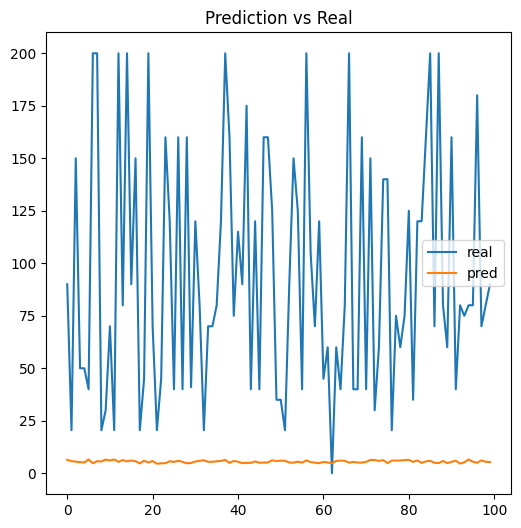

In [78]:

import numpy as np
import matplotlib.pyplot as plt


# convert lists to numpy arrays
real = np.array(actual_real_cost)
pred = np.array(actual_pred_cost)



plt.figure(  figsize=(6,6)  )

plt.plot( real[0:100] ,label="real")

plt.plot( pred[0:100] ,label="pred")

plt.legend()

plt.title("Prediction vs Real")

plt.show()


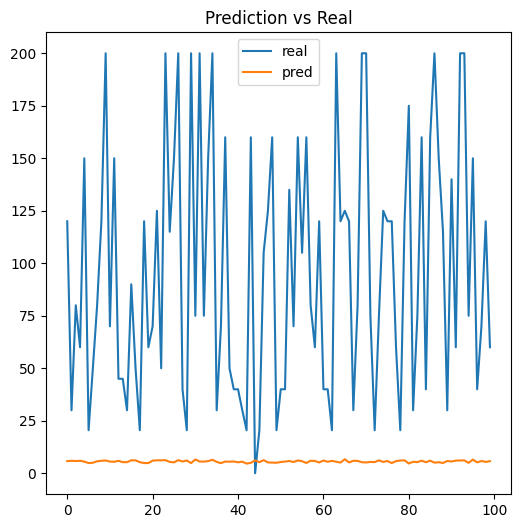

In [79]:

import numpy as np
import matplotlib.pyplot as plt


# convert lists to numpy arrays
real = np.array(actual_real_cost)
pred = np.array(actual_pred_cost)



plt.figure(  figsize=(6,6)  )

plt.plot( real[300:400] ,label="real")

plt.plot( pred[300:400] ,label="pred")

plt.legend()

plt.title("Prediction vs Real")

plt.show()


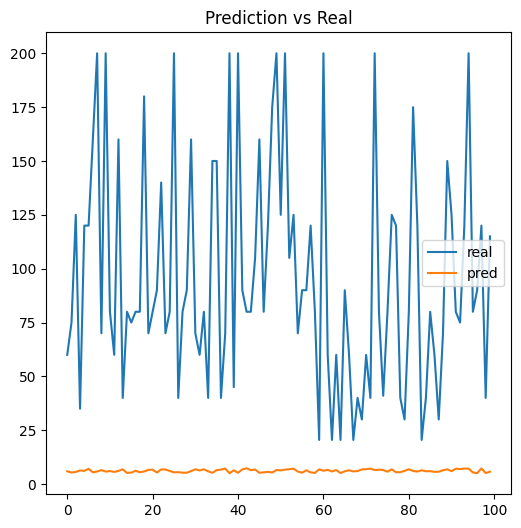

In [80]:

import numpy as np
import matplotlib.pyplot as plt


# convert lists to numpy arrays
real = np.array(actual_real_cost)
pred = np.array(actual_pred_cost)



plt.figure(  figsize=(6,6)  )

plt.plot( real[700:800] ,label="real")

plt.plot( pred[700:800] ,label="pred")

plt.legend()

plt.title("Prediction vs Real")

plt.show()


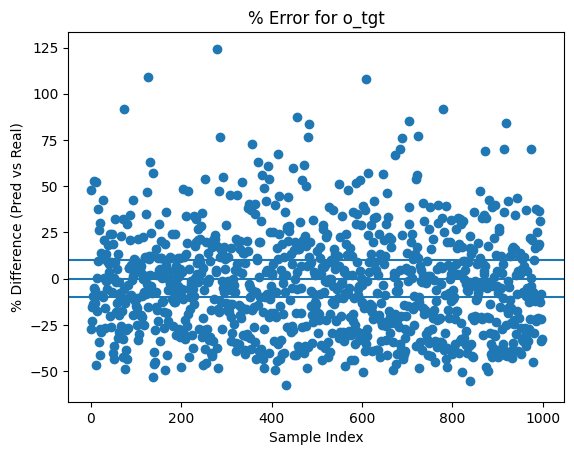

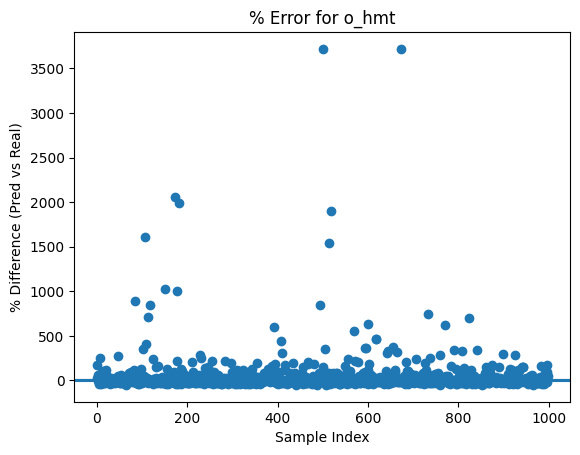

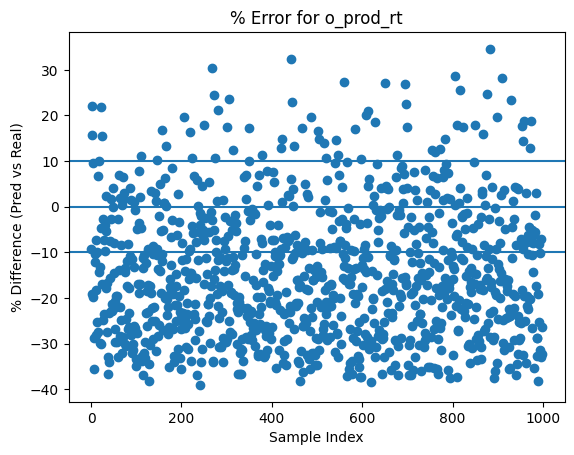

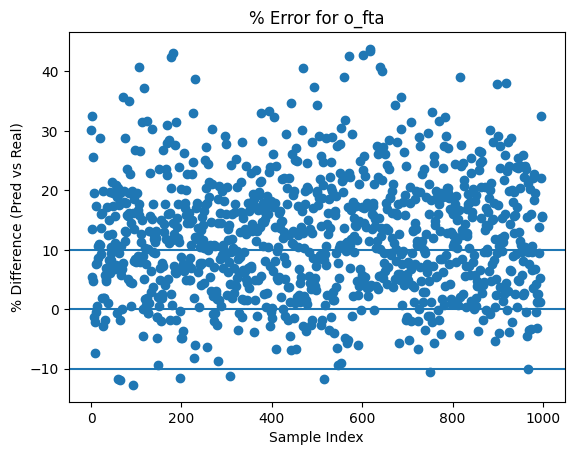

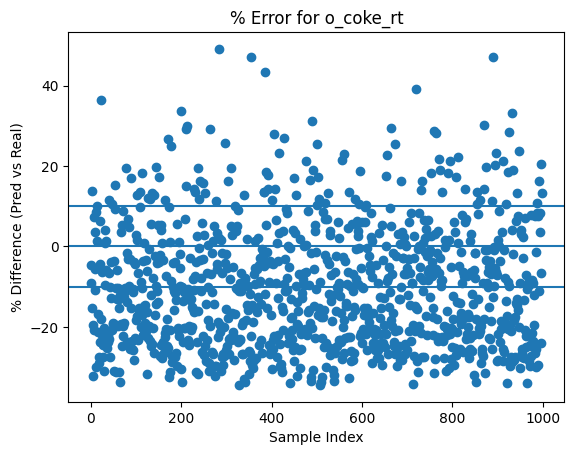

In [81]:

output_names = ['o_tgt', 'o_hmt', 'o_prod_rt', 'o_fta', 'o_coke_rt']

for k in range(5):
    plt.figure()
    plt.scatter(range(len(percent_errors[k])), percent_errors[k])
    
    plt.axhline(0)       # perfect prediction
    plt.axhline(10)      # +10% threshold
    plt.axhline(-10)     # -10% threshold
    
    plt.title(f"% Error for {output_names[k]}")
    plt.xlabel("Sample Index")
    plt.ylabel("% Difference (Pred vs Real)")
    
    plt.show()


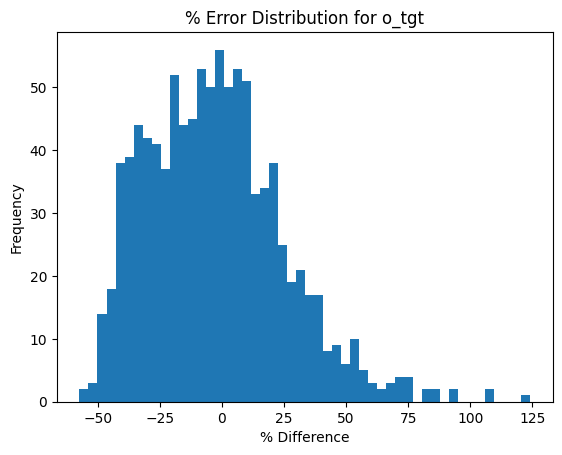

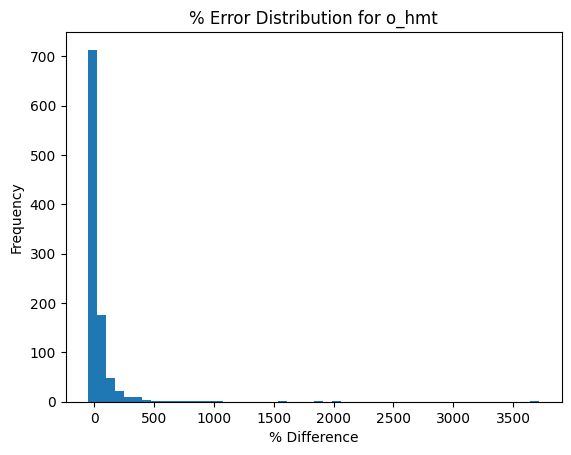

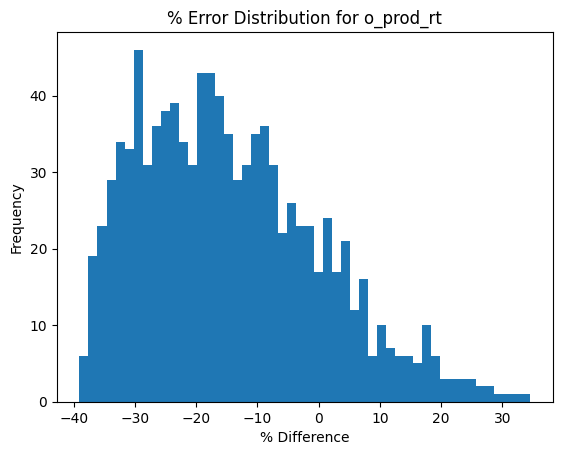

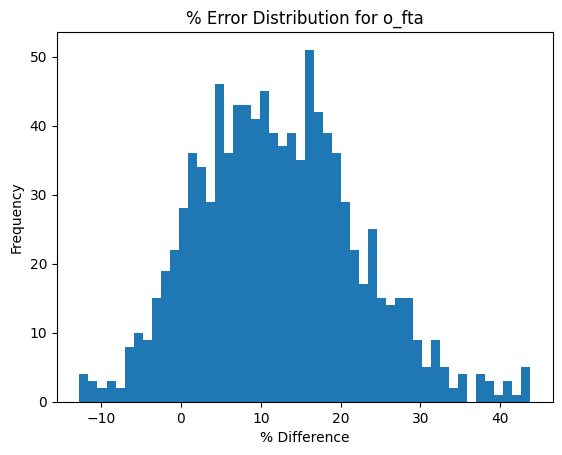

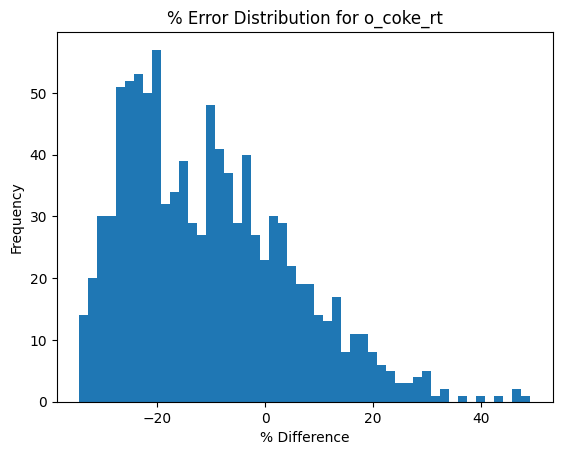

In [82]:

for k in range(5):
    plt.figure()
    plt.hist(percent_errors[k], bins=50)
    plt.title(f"% Error Distribution for {output_names[k]}")
    plt.xlabel("% Difference")
    plt.ylabel("Frequency")
    plt.show()


In [83]:

for k in range(5):
    vals = np.abs(percent_errors[k])
    within_10 = np.mean(vals <= 10) * 100
    within_5  = np.mean(vals <= 5) * 100

    print(output_names[k])
    print("  within 5% :", within_5)
    print("  within 10%:", within_10)


o_tgt
  within 5% : 14.314314314314313
  within 10%: 28.22822822822823
o_hmt
  within 5% : 9.60960960960961
  within 10%: 22.52252252252252
o_prod_rt
  within 5% : 14.614614614614615
  within 10%: 28.428428428428425
o_fta
  within 5% : 22.52252252252252
  within 10%: 42.74274274274275
o_coke_rt
  within 5% : 16.616616616616618
  within 10%: 33.83383383383383


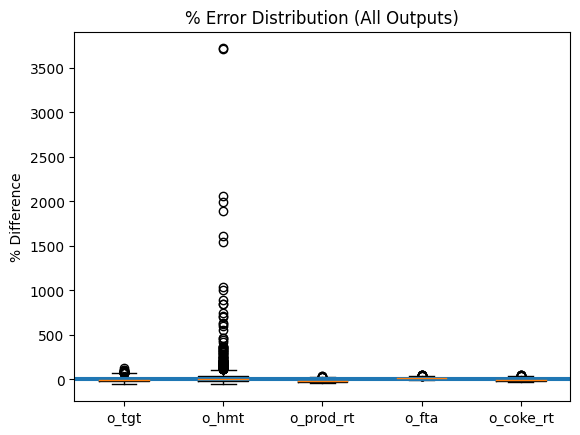

In [84]:

plt.figure()
plt.boxplot(percent_errors)
plt.xticks(range(1,6), output_names)
plt.axhline(10)
plt.axhline(-10)
plt.title("% Error Distribution (All Outputs)")
plt.ylabel("% Difference")
plt.show()


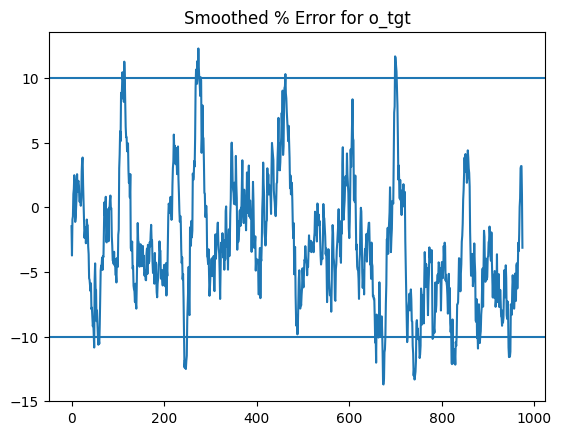

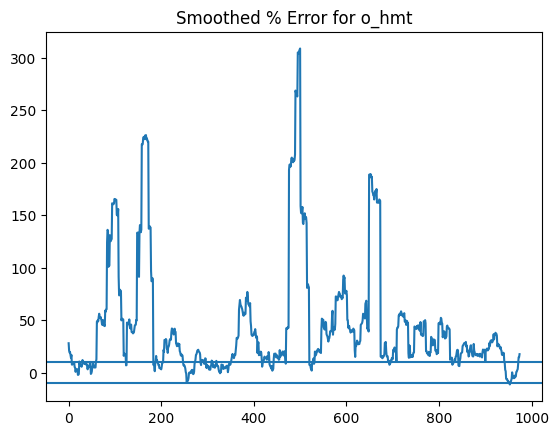

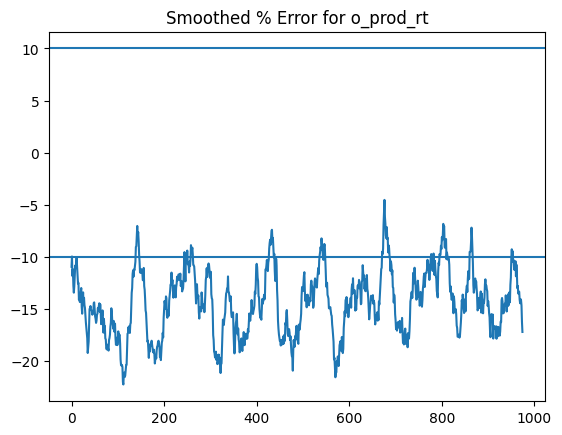

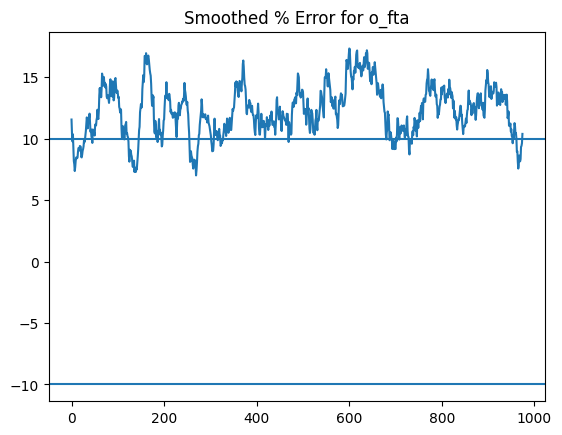

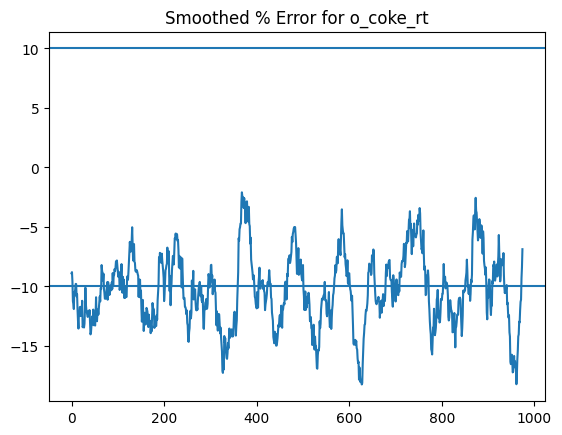

In [85]:

window = 25

for k in range(5):
    vals = np.array(percent_errors[k])
    smooth = np.convolve(vals, np.ones(window)/window, mode='valid')

    plt.figure()
    plt.plot(smooth)
    plt.axhline(10)
    plt.axhline(-10)

    plt.title(f"Smoothed % Error for {output_names[k]}")
    plt.show()


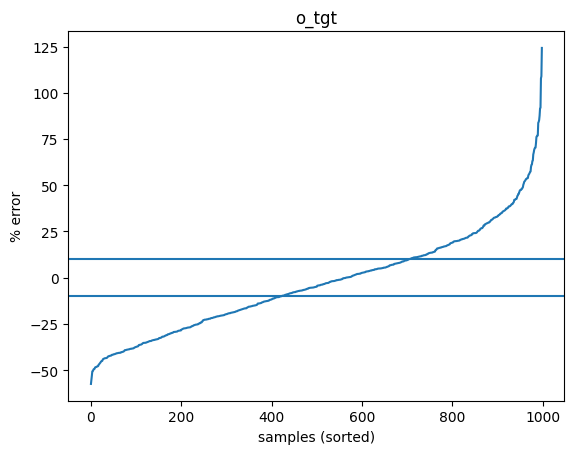

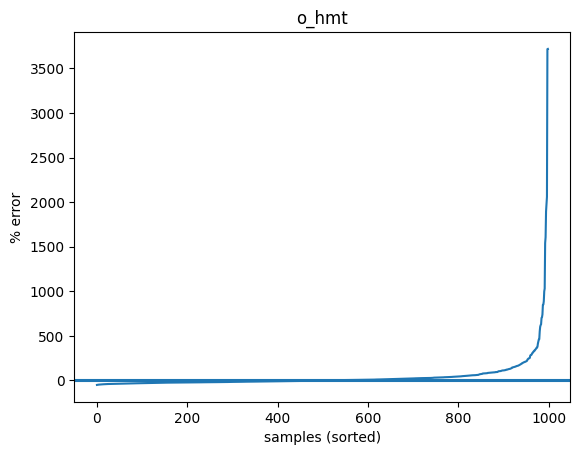

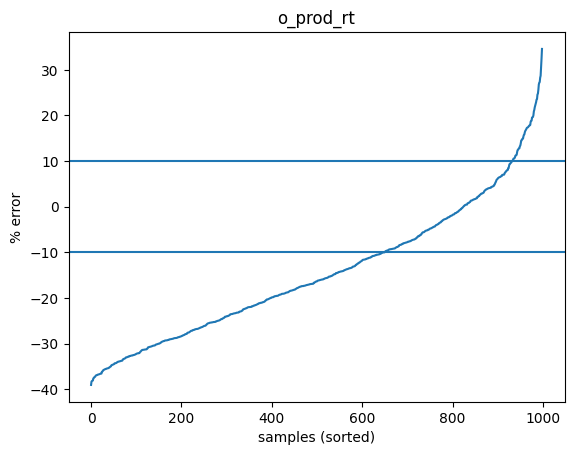

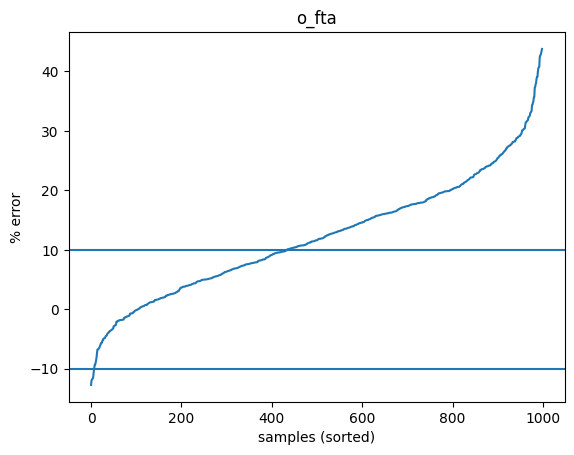

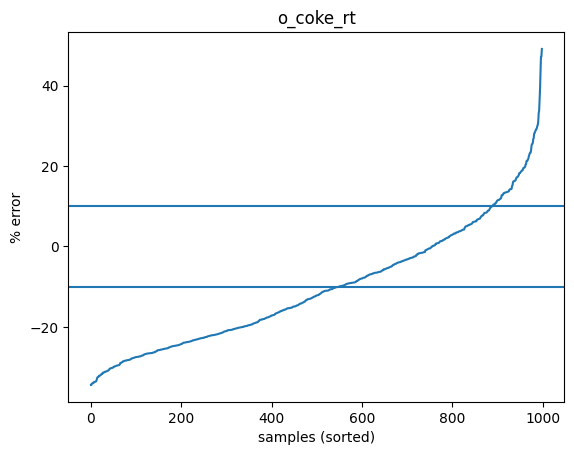

In [86]:

for k in range(5):
    vals = np.sort(np.array(percent_errors[k]))

    plt.figure()
    plt.plot(vals)
    plt.axhline(10)
    plt.axhline(-10)

    plt.title(output_names[k])
    plt.ylabel("% error")
    plt.xlabel("samples (sorted)")
    plt.show()


# 